# Reconnaissance de l’écriture balinaise avec DeepLontar et ResNet18

Ce notebook explique le projet de bout en bout : provenance des données, prévention des fuites, préparation des caractères, entraînement GPU et interprétation des résultats. L’objectif actuel est la **classification de caractères isolés**. Une translittération de page complète nécessitera ensuite un détecteur, la remise en ordre des caractères et des règles linguistiques.

## 1. Résultat obtenu

Le modèle retenu est un ResNet18 préentraîné sur ImageNet, ajusté sur 54 classes DeepLontar. Sur 6 706 caractères issus de manuscrits absents de l’entraînement :

- accuracy : **96,76 %** ;
- macro-précision : **92,74 %** ;
- macro-rappel : **93,56 %** ;
- macro-F1 : **92,91 %**.

La macro-F1 donne le même poids à chaque classe. Elle est plus informative que l’accuracy lorsque certaines classes sont beaucoup plus fréquentes que d’autres.

## 2. Configuration locale

L’expérience a été exécutée sous Windows avec une RTX 5070 Laptop 8 Go. PyTorch 2.9.1 avec CUDA 12.8 est utilisé pour assurer la compatibilité avec l’architecture NVIDIA Blackwell. Le NPU Intel n’est pas utilisé : CUDA est mieux pris en charge par PyTorch pour cet entraînement CNN.

In [1]:
import json
from pathlib import Path

import torch

print('PyTorch :', torch.__version__)
print('CUDA disponible :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))
    print('CUDA PyTorch :', torch.version.cuda)

PyTorch : 2.9.1+cu128
CUDA disponible : True
GPU : NVIDIA GeForce RTX 5070 Laptop GPU
CUDA PyTorch : 12.8


## 3. Dataset DeepLontar

DeepLontar est un dataset public de manuscrits balinais sur feuilles de palmier. Il contient 200 pages originales et 400 variantes produites par niveaux de gris et seuillage adaptatif. Les caractères sont décrits par des annotations YOLO : `classe x_centre y_centre largeur hauteur`, avec des coordonnées normalisées entre 0 et 1.

Téléchargement officiel : https://doi.org/10.6084/m9.figshare.20103803.v2

Les archives doivent être extraites sous `data/deeplontar/images` et `data/deeplontar/labels`.

## 4. Pourquoi un split aléatoire par image serait incorrect

Chaque page originale possède deux versions améliorées partageant exactement les mêmes caractères et coordonnées. Si une version va dans le train et une autre dans le test, le modèle voit presque le même exemple pendant l’apprentissage. L’accuracy devient alors artificiellement élevée.

Le script `prepare_deeplontar.py` regroupe les fichiers qui partagent les mêmes annotations. Un groupe complet est affecté à train, validation ou test. Les variantes améliorées sont conservées uniquement dans le train ; validation et test contiennent uniquement des pages originales.

In [2]:
# Exécuter depuis la racine du dépôt :
# %run ../prepare_deeplontar.py

summary_path = Path('../data/processed/summary.json')
if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    print('Groupes de manuscrits :', summary['groups'])
    print('Échantillons :', summary['samples'])
    print('Classes retenues :', len(summary['retained_classes']))
    print('Classes exclues :', summary['excluded_classes'])
else:
    print('Préparez d’abord les données avec prepare_deeplontar.py')

Groupes de manuscrits : 200
Échantillons : {'train': 95427, 'test': 6706, 'val': 6668}
Classes retenues : 54
Classes exclues : [34]


### Contrôle des classes

Les annotations contiennent quelques IDs hors du schéma déclaré `0–54`. Ils sont ignorés. La classe 34 apparaît dans seulement deux manuscrits : il est impossible de la placer honnêtement dans train, validation et test. Elle est donc exclue de cette première expérience. Le dataset final contient 54 classes, 95 427 crops de train, 6 668 de validation et 6 706 de test.

## 5. Prétraitement

Chaque boîte YOLO est convertie en crop RGB avec 15 % de marge. Pour l’entraînement, le DataModule applique un recadrage aléatoire et une rotation légère, puis la normalisation ImageNet. Pour validation et test, le redimensionnement est déterministe. Les flips sont volontairement évités : retourner un glyph peut changer sa structure.

La taille 128×128 est suffisante pour les caractères isolés et accélère fortement l’entraînement par rapport à 224×224.

In [3]:
import sys
sys.path.insert(0, '..')

from src.data import BalineseDataModule

data = BalineseDataModule(
    data_dir='../data/processed',
    backbone='resnet18',
    image_size=128,
    batch_size=128,
    num_workers=0,  # valeur robuste dans un notebook Windows
)
data.setup()
print('Classes :', data.num_classes)
print('Train / val / test :', len(data.train_dataset), len(data.val_dataset), len(data.test_dataset))

Classes : 54
Train / val / test : 95427 6668 6706


## 6. Architecture du modèle

ResNet18 utilise des connexions résiduelles qui facilitent l’optimisation. Les poids ImageNet fournissent des filtres visuels déjà utiles pour détecter contours et textures. La dernière couche est remplacée par une couche linéaire à 54 sorties.

L’optimiseur est Adam avec un learning rate de `3e-4`. La loss est l’entropie croisée. L’entraînement utilise AMP FP16 pour exploiter les Tensor Cores et réduire la mémoire GPU.

In [4]:
from src.models.lightning_module import BalineseClassifier

model = BalineseClassifier(
    num_classes=data.num_classes,
    backbone='resnet18',
    learning_rate=3e-4,
    pretrained=True,
)
print(f'Paramètres : {sum(p.numel() for p in model.parameters()):,}')

Paramètres : 11,204,214


## 7. Lancer l’entraînement

Pour éviter de bloquer l’interface du notebook sous Windows, l’expérience complète est lancée depuis un terminal à la racine du dépôt :

```powershell
.\.venv\Scripts\python.exe train.py --data-dir data/processed --backbone resnet18 --image-size 128 --batch-size 128 --num-workers 8 --learning-rate 0.0003 --max-epochs 8 --accelerator gpu --devices 1 --precision 16-mixed --checkpoint-dir models/checkpoints/resnet18-128
```

`ModelCheckpoint` conserve le minimum de `val_loss`. `EarlyStopping` arrête l’entraînement après cinq époques sans amélioration.

## 8. Interprétation de la courbe

Le meilleur checkpoint apparaît à l’époque d’indice 1 : `val_loss=0,1446` et `val_acc=97,59 %`. Aux époques suivantes, la loss de train continue de baisser mais la loss de validation augmente. C’est le signe d’un début de surapprentissage. Utiliser le dernier checkpoint aurait donc été moins bon que restaurer automatiquement le meilleur.

In [5]:
metrics_path = Path('../reports/test_metrics.json')
metrics = json.loads(metrics_path.read_text())
for key in ('samples', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1'):
    print(f'{key:>16}: {metrics[key]:.4f}' if isinstance(metrics[key], float) else f'{key:>16}: {metrics[key]}')

         samples: 6706
        accuracy: 0.9676
 macro_precision: 0.9274
    macro_recall: 0.9356
        macro_f1: 0.9291


## 9. Limites observées

L’accuracy globale est élevée, mais les classes rares restent fragiles. `class_50` ne possède que deux exemples de test et obtient un F1 nul. Cela ne prouve pas que l’architecture est mauvaise : le support est insuffisant pour mesurer ou apprendre cette classe. La prochaine collecte doit cibler en priorité les classes 20, 32, 50 et les autres classes ayant peu de manuscrits sources.

In [6]:
worst = sorted(metrics['per_class'], key=lambda row: row['f1'])[:10]
for row in worst:
    print(row['class_name'], 'support=', row['support'], 'F1=', f"{row['f1']:.3f}")

class_50 support= 2 F1= 0.000
class_29 support= 16 F1= 0.750
class_30 support= 10 F1= 0.762
class_49 support= 11 F1= 0.769
class_44 support= 102 F1= 0.825
class_27 support= 9 F1= 0.842
class_31 support= 24 F1= 0.857
class_32 support= 3 F1= 0.857
class_43 support= 167 F1= 0.873
class_38 support= 181 F1= 0.889


## 10. De la classification à la translittération

Ce modèle suppose que le caractère est déjà localisé. Une application finale devra suivre ce pipeline :

1. détecter les caractères dans la page avec YOLO ;
2. recadrer chaque boîte ;
3. prédire sa classe avec ResNet18 ;
4. ordonner les boîtes selon les lignes et leur position ;
5. mapper les IDs vers les glyphes Unicode balinais ;
6. appliquer les règles de composition et produire la translittération latine.

Pour des lignes non segmentées, un CRNN avec CTC ou un Transformer OCR pourra être comparé à cette approche en deux étapes.

## Conclusion

Le résultat constitue une baseline reproductible et crédible : données officielles, séparation par source, test indépendant, métriques macro et checkpoint conservé selon la validation. La priorité scientifique suivante n’est pas d’agrandir immédiatement le réseau, mais d’améliorer les exemples des classes rares et de construire la correspondance classe → Unicode → translittération.

# Démonstration visuelle et exécutable

Les cellules suivantes complètent l’explication avec les plots du dataset, le code d’entraînement, les courbes réellement enregistrées, la matrice de confusion, les erreurs et une fonction de prédiction sur une nouvelle image.

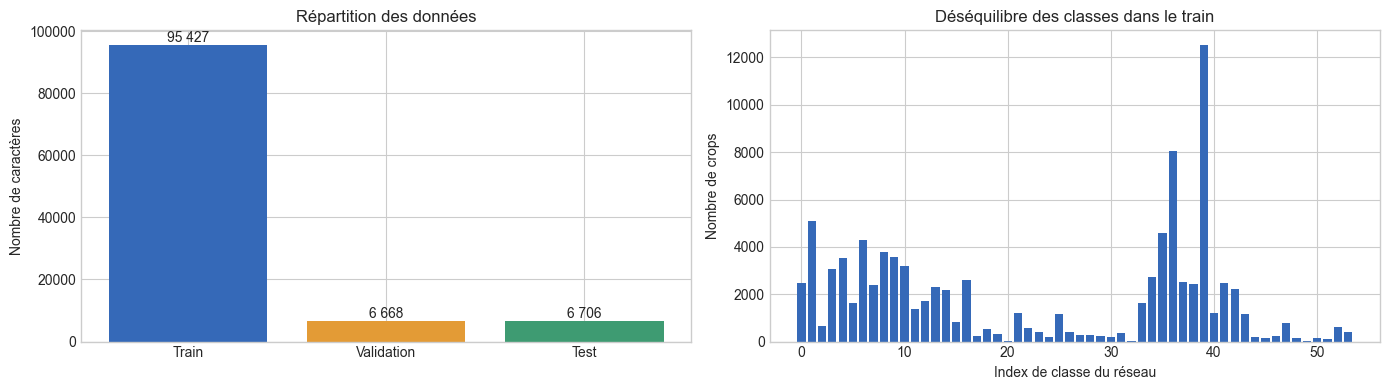

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
split_sizes = {
    'Train': len(data.train_dataset),
    'Validation': len(data.val_dataset),
    'Test': len(data.test_dataset),
}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(list(split_sizes), list(split_sizes.values()), color=['#3569b8', '#e39b36', '#3e9b72'])
axes[0].set_title('Répartition des données')
axes[0].set_ylabel('Nombre de caractères')
for index, value in enumerate(split_sizes.values()):
    axes[0].text(index, value, f'{value:,}'.replace(',', ' '), ha='center', va='bottom')
train_counts = Counter(data.train_dataset.targets)
axes[1].bar(range(data.num_classes), [train_counts[i] for i in range(data.num_classes)], color='#3569b8')
axes[1].set_title('Déséquilibre des classes dans le train')
axes[1].set_xlabel('Index de classe du réseau')
axes[1].set_ylabel('Nombre de crops')
plt.tight_layout()
plt.show()

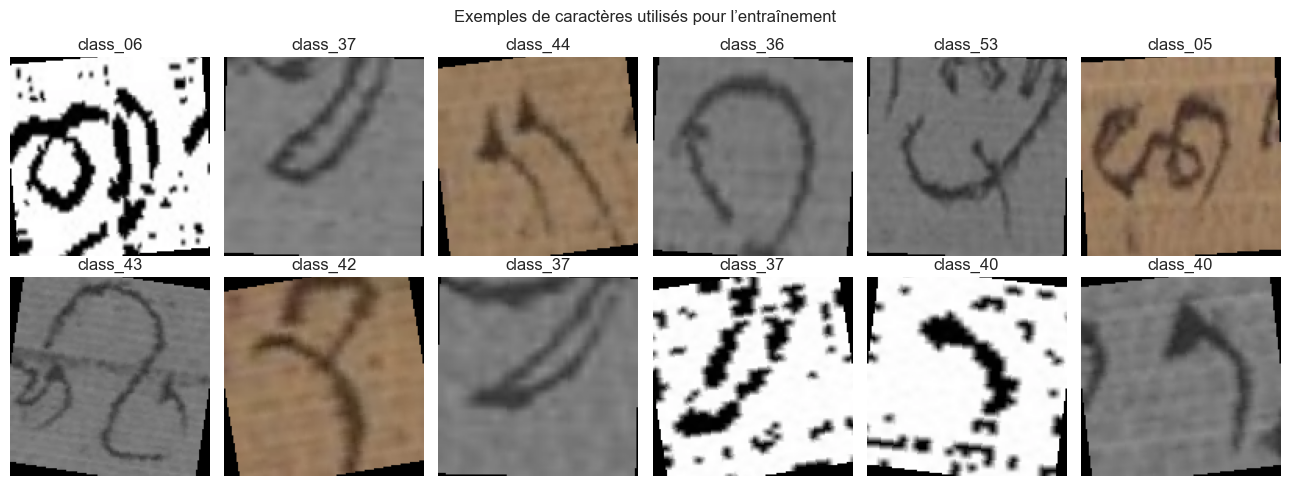

In [8]:
# Aperçu d’un batch après prétraitement.
images, labels = next(iter(data.train_dataloader()))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
fig, axes = plt.subplots(2, 6, figsize=(13, 5))
for axis, image, label in zip(axes.ravel(), images[:12], labels[:12]):
    display_image = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)
    axis.imshow(display_image)
    axis.set_title(data.class_names[int(label)])
    axis.axis('off')
plt.suptitle('Exemples de caractères utilisés pour l’entraînement')
plt.tight_layout()
plt.show()

## Entraînement exécutable

Passer `RUN_TRAINING` à `True` pour relancer l’expérience. La valeur est désactivée par défaut afin que l’ouverture du notebook ne déclenche pas automatiquement plusieurs minutes de calcul et ne remplace pas le checkpoint validé.

In [9]:
import lightning as L
from src.models.callbacks import build_training_callbacks

RUN_TRAINING = False
if RUN_TRAINING:
    torch.set_float32_matmul_precision('high')
    demo_model = BalineseClassifier(
        num_classes=data.num_classes, backbone='resnet18',
        learning_rate=3e-4, pretrained=True,
    )
    trainer = L.Trainer(
        max_epochs=8, accelerator='gpu', devices=1, precision='16-mixed',
        callbacks=build_training_callbacks('../models/checkpoints/resnet18-128'),
        log_every_n_steps=10,
    )
    trainer.fit(demo_model, datamodule=data)
    trainer.test(demo_model, datamodule=data, ckpt_path='best')
else:
    print('Entraînement non relancé : résultats réels chargés depuis reports/.')

Entraînement non relancé : résultats réels chargés depuis reports/.


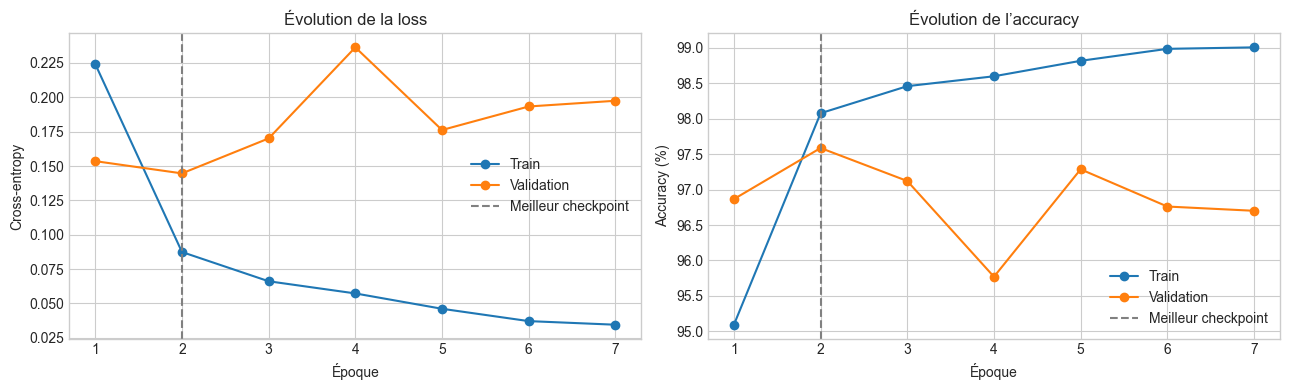

In [10]:
# Courbes issues de l’entraînement réel effectué sur la RTX 5070.
history = json.loads(Path('../reports/training_history.json').read_text())
epochs = [row['epoch'] + 1 for row in history]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs, [row['train_loss'] for row in history], marker='o', label='Train')
axes[0].plot(epochs, [row['val_loss'] for row in history], marker='o', label='Validation')
axes[0].axvline(2, color='gray', linestyle='--', label='Meilleur checkpoint')
axes[0].set(title='Évolution de la loss', xlabel='Époque', ylabel='Cross-entropy')
axes[0].legend()
axes[1].plot(epochs, [100 * row['train_acc'] for row in history], marker='o', label='Train')
axes[1].plot(epochs, [100 * row['val_acc'] for row in history], marker='o', label='Validation')
axes[1].axvline(2, color='gray', linestyle='--', label='Meilleur checkpoint')
axes[1].set(title='Évolution de l’accuracy', xlabel='Époque', ylabel='Accuracy (%)')
axes[1].legend()
plt.tight_layout()
plt.show()

## Évaluation et test du meilleur checkpoint

La matrice de confusion montre les vraies classes sur l’axe vertical et les prédictions sur l’axe horizontal. Une diagonale forte indique des prédictions correctes.

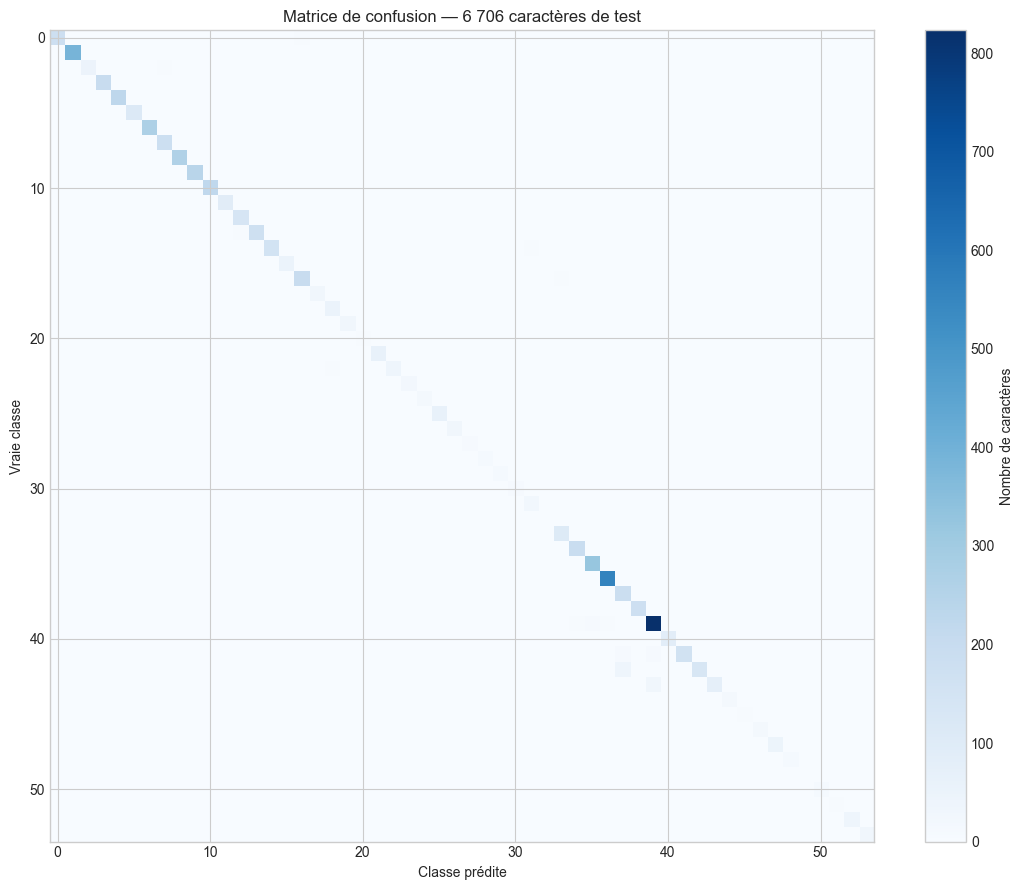

In [11]:
confusion = np.asarray(metrics['confusion_matrix'])
fig, axis = plt.subplots(figsize=(11, 9))
image_plot = axis.imshow(confusion, cmap='Blues', aspect='auto')
axis.set_title('Matrice de confusion — 6 706 caractères de test')
axis.set_xlabel('Classe prédite')
axis.set_ylabel('Vraie classe')
fig.colorbar(image_plot, ax=axis, label='Nombre de caractères')
plt.tight_layout()
plt.show()

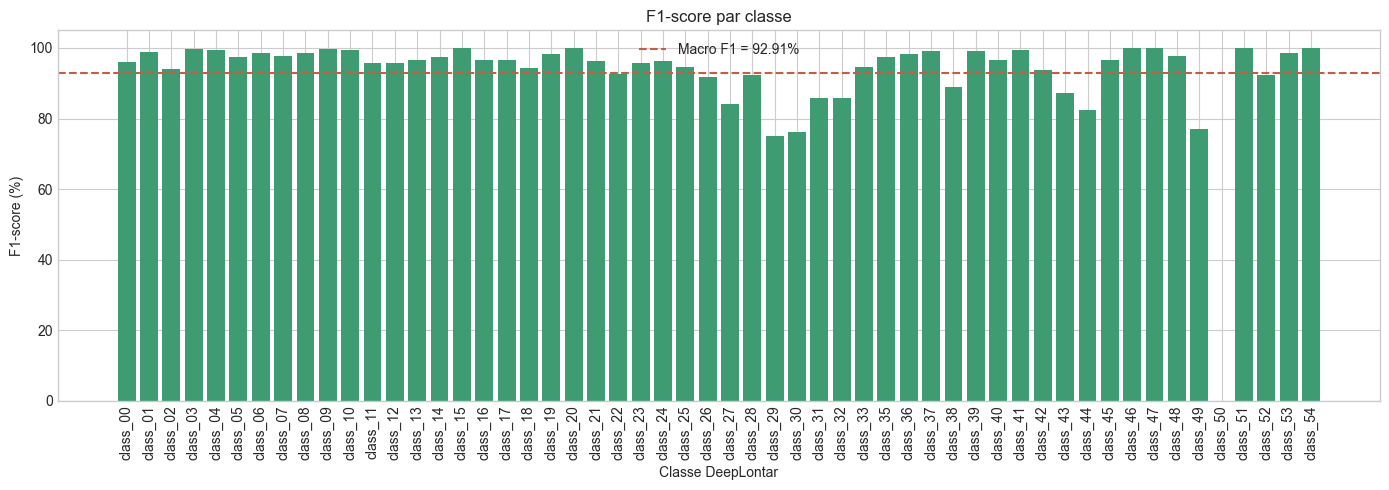

In [12]:
per_class = metrics['per_class']
fig, axis = plt.subplots(figsize=(14, 5))
axis.bar([row['class_name'] for row in per_class], [100 * row['f1'] for row in per_class], color='#3e9b72')
axis.axhline(100 * metrics['macro_f1'], color='#c45d45', linestyle='--', label=f"Macro F1 = {100*metrics['macro_f1']:.2f}%")
axis.set(title='F1-score par classe', xlabel='Classe DeepLontar', ylabel='F1-score (%)', ylim=(0, 105))
axis.tick_params(axis='x', rotation=90)
axis.legend()
plt.tight_layout()
plt.show()

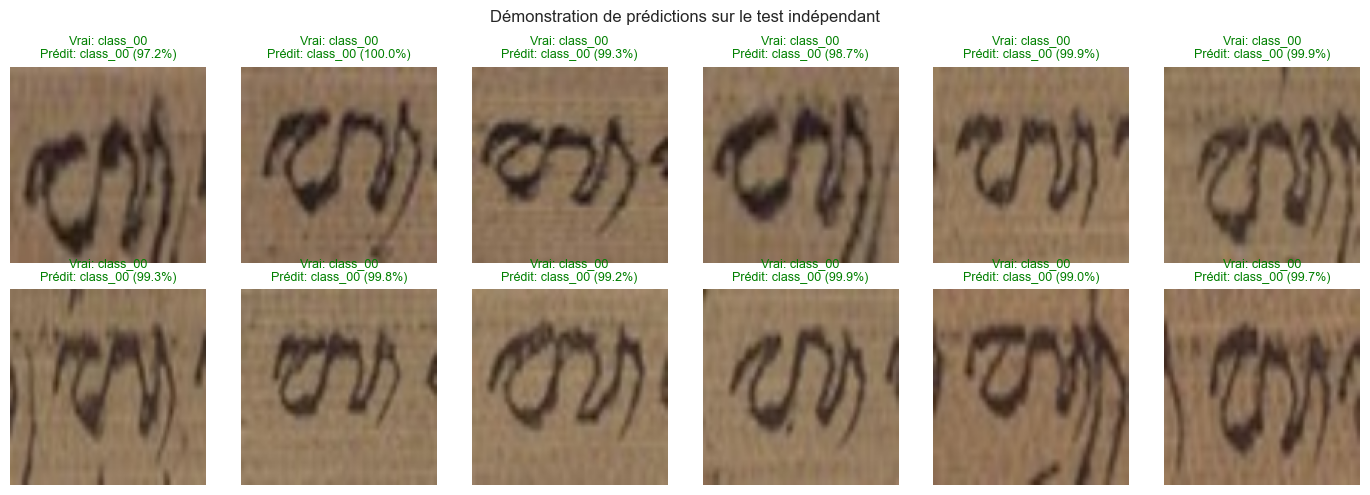

In [13]:
# Chargement du meilleur modèle et démonstration sur des images de test.
checkpoint = next(Path('../models/checkpoints/resnet18-128').glob('best-*.ckpt'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = BalineseClassifier.load_from_checkpoint(checkpoint, map_location=device).to(device).eval()
test_images, test_labels = next(iter(data.test_dataloader()))
with torch.inference_mode():
    probabilities = best_model(test_images.to(device)).softmax(dim=1).cpu()
predictions = probabilities.argmax(dim=1)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for axis, image, truth, prediction, probability in zip(
    axes.ravel(), test_images[:12], test_labels[:12], predictions[:12], probabilities[:12]
):
    display_image = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)
    axis.imshow(display_image)
    correct = int(truth) == int(prediction)
    axis.set_title(
        f"Vrai: {data.class_names[int(truth)]}\nPrédit: {data.class_names[int(prediction)]} ({100*probability.max():.1f}%)",
        color='green' if correct else 'red', fontsize=9,
    )
    axis.axis('off')
plt.suptitle('Démonstration de prédictions sur le test indépendant')
plt.tight_layout()
plt.show()

## Tester une nouvelle image

La fonction suivante applique exactement le prétraitement du test et retourne les cinq classes les plus probables. Remplacer le chemin d’exemple par un crop contenant un seul caractère.

In [14]:
from PIL import Image

def predict_character(image_path, top_k=5):
    image = Image.open(image_path).convert('RGB')
    tensor = data.eval_transforms(image).unsqueeze(0).to(device)
    with torch.inference_mode():
        scores = best_model(tensor).softmax(dim=1)[0].cpu()
    values, indices = scores.topk(top_k)
    return [(data.class_names[int(index)], float(value)) for value, index in zip(values, indices)]

example_path, _ = data.test_dataset.samples[0]
print('Image :', example_path)
for class_name, confidence in predict_character(example_path):
    print(f'{class_name:>10} : {confidence:.2%}')

Image : ..\data\processed\test\class_00\100b_0161.jpg
  class_00 : 97.23%
  class_16 : 2.48%
  class_06 : 0.17%
  class_40 : 0.01%
  class_41 : 0.01%
